# Revenue Anomaly Detection for a Finance Business

Goal is to build an anomaly detection workflow that answers:

1. Which revenue days look abnormal?
2. Are they positive spikes or negative drops?
3. What business factors explain the anomaly?
4. Could the anomaly be caused by a real business event, fraud, billing issue, or data pipeline problem?



In [1]:
# Install if needed in Colab
# !pip install pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


# 1. Create realistic revenue dataset

The synthetic dataset simulates a subscription company with data related to:

- Monthly subscription renewals
- Weekly seasonality
- Marketing campaign days
- Payment gateway outages
- Refund spikes
- Fraud / chargeback days
- Data pipeline duplicate events
- Enterprise invoice days


In [2]:

# Generate daily dates
start_date = '2024-01-01'
end_date = '2025-06-30'
dates = pd.date_range(start=start_date, end=end_date, freq='D')
n = len(dates)

# Base trend: business grows slowly over time
trend = np.linspace(0, 9000, n)

# Weekly seasonality: weekdays stronger than weekends
weekday = dates.weekday
weekly_effect = np.where(weekday < 5, 3000, -2500)

# Month start renewal effect: many subscriptions renew at start of month
month_start_effect = np.where(dates.day <= 3, 7000, 0)

# Normal random noise
noise = np.random.normal(0, 2200, n)

# Revenue baseline
base_revenue = 52000 + trend + weekly_effect + month_start_effect + noise

# Supporting metrics
transactions = (base_revenue / 95 + np.random.normal(0, 35, n)).astype(int)
new_customers = np.random.poisson(lam=70, size=n) + (trend / 1000).astype(int)
active_subscribers = 42000 + np.linspace(0, 8500, n).astype(int) + np.random.normal(0, 300, n).astype(int)
refund_amount = np.random.gamma(shape=2.0, scale=700, size=n)
failed_payments = np.random.poisson(lam=35, size=n)
chargebacks = np.random.poisson(lam=3, size=n)
discount_rate = np.clip(np.random.normal(0.08, 0.025, n), 0.02, 0.20)
marketing_spend = np.random.gamma(shape=2.0, scale=1800, size=n)
enterprise_invoice_amount = np.zeros(n)
payment_gateway_latency_ms = np.random.normal(230, 45, n)
etl_delay_minutes = np.random.poisson(lam=8, size=n)

# Create dataframe
df = pd.DataFrame({
    'date': dates,
    'gross_revenue': base_revenue,
    'transactions': transactions,
    'new_customers': new_customers,
    'active_subscribers': active_subscribers,
    'refund_amount': refund_amount,
    'failed_payments': failed_payments,
    'chargebacks': chargebacks,
    'discount_rate': discount_rate,
    'marketing_spend': marketing_spend,
    'enterprise_invoice_amount': enterprise_invoice_amount,
    'payment_gateway_latency_ms': payment_gateway_latency_ms,
    'etl_delay_minutes': etl_delay_minutes
})

# Inject realistic known anomalies with business causes
anomaly_events = [
    # date, revenue impact, cause, supporting metric changes
    ('2024-02-14', 38000, 'Valentine promotion drove unusually high new subscriptions', {'marketing_spend': 42000, 'new_customers': 260, 'transactions': 520}),
    ('2024-03-31', 85000, 'Quarter-end enterprise invoice booked', {'enterprise_invoice_amount': 85000, 'transactions': 80}),
    ('2024-05-09', -42000, 'Payment gateway outage caused failed payments and revenue drop', {'failed_payments': 470, 'payment_gateway_latency_ms': 1600, 'transactions': -360}),
    ('2024-07-04', -28000, 'Holiday demand slowdown', {'new_customers': -45, 'transactions': -260}),
    ('2024-09-16', 62000, 'Duplicate billing / ETL duplicate load issue', {'etl_delay_minutes': 185, 'transactions': 15}),
    ('2024-11-29', 74000, 'Black Friday campaign revenue spike', {'marketing_spend': 68000, 'new_customers': 420, 'transactions': 760, 'discount_rate': 0.24}),
    ('2025-01-02', -52000, 'Refund processing backlog released after holidays', {'refund_amount': 54000, 'transactions': -110}),
    ('2025-03-15', 47000, 'Suspicious fraud-like payment burst', {'chargebacks': 85, 'transactions': 610}),
    ('2025-05-30', -36000, 'Subscription renewal job failed for part of customer base', {'failed_payments': 380, 'etl_delay_minutes': 145, 'transactions': -310}),
]

# Apply anomalies
known_anomaly_dates = []
for event_date, revenue_impact, cause, changes in anomaly_events:
    idx = df.index[df['date'] == pd.to_datetime(event_date)][0]
    known_anomaly_dates.append(pd.to_datetime(event_date))
    df.loc[idx, 'gross_revenue'] += revenue_impact
    df.loc[idx, 'known_cause'] = cause

    for col, change in changes.items():
        if col in ['marketing_spend', 'enterprise_invoice_amount', 'refund_amount', 'payment_gateway_latency_ms', 'etl_delay_minutes', 'failed_payments', 'chargebacks']:
            df.loc[idx, col] += change
        elif col in ['new_customers', 'transactions']:
            df.loc[idx, col] = max(0, df.loc[idx, col] + change)
        elif col == 'discount_rate':
            df.loc[idx, col] = change

# Net revenue after refunds
df['net_revenue'] = df['gross_revenue'] - df['refund_amount']
df['avg_order_value'] = df['gross_revenue'] / df['transactions'].replace(0, np.nan)
df['is_known_anomaly'] = df['date'].isin(known_anomaly_dates).astype(int)
df['known_cause'] = df['known_cause'].fillna('Normal business day')

# Clean numeric values
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col not in ['discount_rate']:
        df[col] = df[col].clip(lower=0)

df.head()


,date,gross_revenue,transactions,new_customers,active_subscribers,refund_amount,failed_payments,chargebacks,discount_rate,marketing_spend,enterprise_invoice_amount,payment_gateway_latency_ms,etl_delay_minutes,known_cause,net_revenue,avg_order_value,is_known_anomaly
0,2024-01-01,63092.771137,657,48,42030,1960.909320,28,3,0.090986,5451.380528,0.0,244.587979,5,Normal business day,61131.861816,96.031615,0
1,2024-01-02,61712.302054,662,69,42479,791.981685,39,4,0.111699,2381.288476,0.0,228.143834,10,Normal business day,60920.320369,93.221000,0
2,2024-01-03,63457.881817,646,65,41660,1851.554793,42,6,0.079390,6546.300059,0.0,327.160452,6,Normal business day,61606.327024,98.232015,0
3,2024-01-04,58400.116234,617,49,41606,2562.408897,36,4,0.044444,2455.265421,0.0,234.109163,6,Normal business day,55837.707337,94.651728,0
4,2024-01-05,54550.796642,568,73,42111,576.380082,39,4,0.101063,2320.459330,0.0,212.879484,8,Normal business day,53974.416560,96.040135,0


In [3]:
# Save dataset so you can use it separately
df.to_csv('synthetic_finance_revenue_anomaly_dataset.csv', index=False)
print('Dataset shape:', df.shape)
df.sample(5, random_state=42)


Dataset shape: (547, 17)


,date,gross_revenue,transactions,new_customers,active_subscribers,refund_amount,failed_payments,chargebacks,discount_rate,marketing_spend,enterprise_invoice_amount,payment_gateway_latency_ms,etl_delay_minutes,known_cause,net_revenue,avg_order_value,is_known_anomaly
176,2024-06-25,57929.703063,635,69,44808,1081.083717,31,2,0.072428,5384.085893,0.0,256.325960,6,Normal business day,56848.619346,91.227879,0
77,2024-03-18,55611.414598,641,63,43063,2658.961316,28,2,0.048263,379.555663,0.0,293.511059,12,Normal business day,52952.453282,86.757277,0
361,2024-12-27,64322.575059,699,68,47536,4007.804693,34,3,0.056945,2231.983037,0.0,221.552284,6,Normal business day,60314.770366,92.020851,0
90,2024-03-31,136197.087092,621,58,43826,531.797542,37,4,0.034258,1190.348950,85000.0,265.508384,5,Quarter-end enterprise invoice booked,135665.289550,219.318981,1
368,2025-01-03,68280.821483,728,75,47403,516.996554,25,2,0.073386,6341.059702,0.0,303.864288,10,Normal business day,67763.824929,93.792337,0


# 2. Data dictionary

| Column | Meaning |
|---|---|
| date | Calendar date |
| gross_revenue | Daily gross revenue before refunds |
| refund_amount | Refunds processed that day |
| net_revenue | Gross revenue minus refunds |
| transactions | Number of successful transactions |
| new_customers | New customers acquired that day |
| active_subscribers | Active paying subscriber base |
| failed_payments | Failed payment attempts |
| chargebacks | Disputed / reversed payments |
| discount_rate | Average discount rate |
| marketing_spend | Daily marketing campaign spend |
| enterprise_invoice_amount | Large B2B invoice amount |
| payment_gateway_latency_ms | Payment system latency |
| etl_delay_minutes | Data pipeline delay |
| is_known_anomaly | Synthetic truth label for injected anomalies |
| known_cause | Actual injected cause for learning |


# 3. EDA: Understand normal revenue behavior

In [4]:
df[['gross_revenue', 'net_revenue', 'transactions', 'new_customers', 'refund_amount', 'failed_payments']].describe().T

,count,mean,std,min,25%,50%,75%,max
gross_revenue,547.0,58856.551592,8038.745155,14018.727187,55329.583861,58507.606805,61775.825746,136197.087092
net_revenue,547.0,57397.912631,8240.026504,0.000000,53899.519140,57093.158867,60434.657604,135665.289550
transactions,547.0,620.756856,78.810975,190.000000,581.000000,618.000000,657.000000,1469.000000
new_customers,547.0,74.855576,22.735523,38.000000,67.000000,74.000000,80.000000,489.000000
refund_amount,547.0,1531.250568,2534.362914,50.755501,686.730358,1229.994778,1914.748893,55795.702534
failed_payments,547.0,36.383912,26.894427,20.000000,31.000000,35.000000,39.000000,512.000000


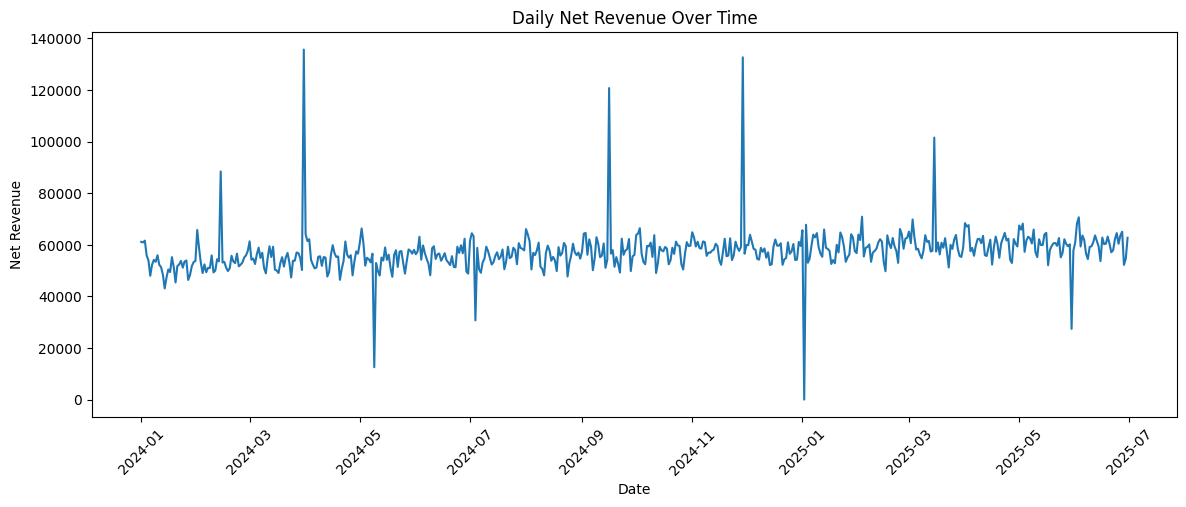

In [5]:
plt.figure(figsize=(14,5))
plt.plot(df['date'], df['net_revenue'])
plt.title('Daily Net Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Net Revenue')
plt.xticks(rotation=45)
plt.show()


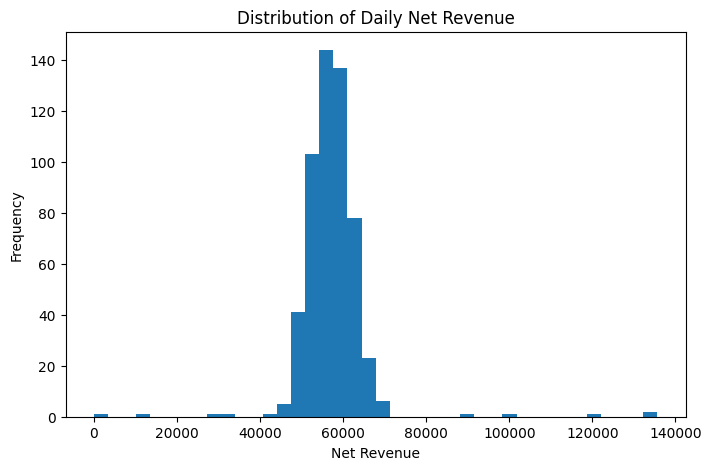

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df['net_revenue'], bins=40)
plt.title('Distribution of Daily Net Revenue')
plt.xlabel('Net Revenue')
plt.ylabel('Frequency')
plt.show()


In [7]:
# Revenue by day of week
df['day_of_week'] = df['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_summary = df.groupby('day_of_week')['net_revenue'].agg(['mean','median','std','count']).reindex(dow_order)
dow_summary


,mean,median,std,count
day_of_week,,,,
Monday,59482.462098,59095.683202,8226.855781,79
Tuesday,58810.287011,58892.849212,3901.154779,78
Wednesday,58742.114792,58525.441717,4960.224253,78
Thursday,57040.603098,58365.231879,9769.291840,78
Friday,59150.303043,58500.994487,9911.328625,78
Saturday,54108.187479,53030.210262,6880.612649,78
Sunday,54424.705902,53605.452561,10029.584286,78


# 4. Feature engineering

Anomaly detection improves when we compare today's revenue against recent behavior.

We create:

- Lag revenue
- Rolling 7-day average
- Rolling 7-day standard deviation
- Revenue growth percentage
- Revenue per transaction
- Refund rate
- Failed payment rate
- Chargeback rate


In [8]:

df = df.sort_values('date').reset_index(drop=True)

# Time features
df['day_num'] = np.arange(len(df))
df['is_weekend'] = df['date'].dt.weekday.isin([5,6]).astype(int)
df['is_month_start'] = (df['date'].dt.day <= 3).astype(int)
df['is_month_end'] = (df['date'].dt.is_month_end).astype(int)

# Lag and rolling features
df['net_revenue_lag_1'] = df['net_revenue'].shift(1)
df['net_revenue_lag_7'] = df['net_revenue'].shift(7)
df['rolling_7d_avg_revenue'] = df['net_revenue'].rolling(7).mean()
df['rolling_7d_std_revenue'] = df['net_revenue'].rolling(7).std()
df['rolling_30d_avg_revenue'] = df['net_revenue'].rolling(30).mean()

# Growth and ratio features
df['revenue_growth_pct'] = df['net_revenue'].pct_change()
df['revenue_vs_7d_avg_pct'] = (df['net_revenue'] - df['rolling_7d_avg_revenue']) / df['rolling_7d_avg_revenue']
df['refund_rate'] = df['refund_amount'] / df['gross_revenue'].replace(0, np.nan)
df['failed_payment_rate'] = df['failed_payments'] / (df['transactions'] + df['failed_payments']).replace(0, np.nan)
df['chargeback_rate'] = df['chargebacks'] / df['transactions'].replace(0, np.nan)
df['marketing_efficiency'] = df['gross_revenue'] / df['marketing_spend'].replace(0, np.nan)

# Fill missing values created by rolling/lag calculations
feature_fill_cols = [
    'net_revenue_lag_1','net_revenue_lag_7','rolling_7d_avg_revenue','rolling_7d_std_revenue',
    'rolling_30d_avg_revenue','revenue_growth_pct','revenue_vs_7d_avg_pct',
    'refund_rate','failed_payment_rate','chargeback_rate','marketing_efficiency'
]
for col in feature_fill_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = df[col].fillna(df[col].median())

df.head(10)


,date,gross_revenue,transactions,new_customers,active_subscribers,refund_amount,failed_payments,chargebacks,discount_rate,marketing_spend,enterprise_invoice_amount,payment_gateway_latency_ms,etl_delay_minutes,known_cause,net_revenue,avg_order_value,is_known_anomaly,day_of_week,day_num,is_weekend,is_month_start,is_month_end,net_revenue_lag_1,net_revenue_lag_7,rolling_7d_avg_revenue,rolling_7d_std_revenue,rolling_30d_avg_revenue,revenue_growth_pct,revenue_vs_7d_avg_pct,refund_rate,failed_payment_rate,chargeback_rate,marketing_efficiency
0,2024-01-01,63092.771137,657,48,42030,1960.909320,28,3,0.090986,5451.380528,0.0,244.587979,5,Normal business day,61131.861816,96.031615,0,Monday,0,0,1,0,57090.559075,57069.430518,57451.302203,3890.520185,57430.40784,0.003537,0.005016,0.031080,0.040876,0.004566,11.573724
1,2024-01-02,61712.302054,662,69,42479,791.981685,39,4,0.111699,2381.288476,0.0,228.143834,10,Normal business day,60920.320369,93.221000,0,Tuesday,1,0,1,0,61131.861816,57069.430518,57451.302203,3890.520185,57430.40784,-0.003460,0.005016,0.012833,0.055635,0.006042,25.915509
2,2024-01-03,63457.881817,646,65,41660,1851.554793,42,6,0.079390,6546.300059,0.0,327.160452,6,Normal business day,61606.327024,98.232015,0,Wednesday,2,0,1,0,60920.320369,57069.430518,57451.302203,3890.520185,57430.40784,0.011261,0.005016,0.029178,0.061047,0.009288,9.693702
3,2024-01-04,58400.116234,617,49,41606,2562.408897,36,4,0.044444,2455.265421,0.0,234.109163,6,Normal business day,55837.707337,94.651728,0,Thursday,3,0,0,0,61606.327024,57069.430518,57451.302203,3890.520185,57430.40784,-0.093637,0.005016,0.043877,0.055130,0.006483,23.785663
4,2024-01-05,54550.796642,568,73,42111,576.380082,39,4,0.101063,2320.459330,0.0,212.879484,8,Normal business day,53974.416560,96.040135,0,Friday,4,0,0,0,55837.707337,57069.430518,57451.302203,3890.520185,57430.40784,-0.033370,0.005016,0.010566,0.064250,0.007042,23.508620
5,2024-01-06,49067.316277,557,69,42092,1080.895948,37,2,0.098874,7115.487689,0.0,201.629370,11,Normal business day,47986.420329,88.092130,0,Saturday,5,1,0,0,53974.416560,57069.430518,57451.302203,3890.520185,57430.40784,-0.110941,0.005016,0.022029,0.062290,0.003591,6.895847
6,2024-01-07,53073.169293,567,70,42145,768.047120,41,1,0.031454,895.468320,0.0,303.668708,8,Normal business day,52305.122173,93.603473,0,Sunday,6,1,0,0,47986.420329,57069.430518,56251.739373,5220.660246,57430.40784,0.089998,-0.070160,0.014471,0.067434,0.001764,59.268617
7,2024-01-08,56803.741020,609,59,42181,2644.813029,39,1,0.079905,6004.379655,0.0,194.893525,11,Normal business day,54158.927991,93.273795,0,Monday,7,0,0,0,52305.122173,61131.861816,55255.605969,4781.039855,57430.40784,0.035442,-0.019847,0.046561,0.060185,0.001642,9.460385
8,2024-01-09,54099.024483,555,65,42058,705.681588,42,1,0.040246,416.666565,0.0,263.087119,8,Normal business day,53393.342894,97.475720,0,Tuesday,8,0,0,0,54158.927991,60920.320369,54180.323473,4091.362038,57430.40784,-0.014136,-0.014525,0.013044,0.070352,0.001802,129.837691
9,2024-01-10,56341.983744,576,62,42586,382.968644,38,4,0.063384,6012.128037,0.0,204.837627,10,Normal business day,55959.015100,97.815944,0,Wednesday,9,0,0,0,53393.342894,61606.327024,53373.564626,2704.861557,57430.40784,0.048052,0.048441,0.006797,0.061889,0.006944,9.371388


# 5. Method 1: Z-score anomaly detection

Baby explanation:

- Calculate average revenue
- Calculate how much revenue usually moves
- If one day is very far from the average, flag it

Formula:

```text
z_score = (today revenue - average revenue) / standard deviation
```

Common rule:

```text
absolute z_score > 3 means anomaly
```


In [9]:
revenue_mean = df['net_revenue'].mean()
revenue_std = df['net_revenue'].std()

df['z_score_revenue'] = (df['net_revenue'] - revenue_mean) / revenue_std
df['zscore_anomaly'] = (df['z_score_revenue'].abs() > 3).astype(int)

z_anomalies = df[df['zscore_anomaly'] == 1][['date','net_revenue','z_score_revenue','known_cause']]
z_anomalies


,date,net_revenue,z_score_revenue,known_cause
44,2024-02-14,88424.367546,3.765334,Valentine promotion drove unusually high new s...
90,2024-03-31,135665.289550,9.498438,Quarter-end enterprise invoice booked
129,2024-05-09,12533.009059,-5.444752,Payment gateway outage caused failed payments ...
185,2024-07-04,30705.492097,-3.239361,Holiday demand slowdown
259,2024-09-16,120742.199005,7.687389,Duplicate billing / ETL duplicate load issue
333,2024-11-29,132656.186393,9.133256,Black Friday campaign revenue spike
367,2025-01-02,0.000000,-6.965744,Refund processing backlog released after holidays
439,2025-03-15,101537.112141,5.356682,Suspicious fraud-like payment burst
515,2025-05-30,27401.789711,-3.640294,Subscription renewal job failed for part of cu...


# 6. Method 2: Rolling anomaly detection

A global average can miss seasonality and growth. A better finance method compares today against the recent 30-day baseline.


In [10]:
df['rolling_30d_std_revenue'] = df['net_revenue'].rolling(30).std().fillna(df['net_revenue'].std())
df['rolling_anomaly_score'] = (df['net_revenue'] - df['rolling_30d_avg_revenue']) / df['rolling_30d_std_revenue']
df['rolling_anomaly'] = (df['rolling_anomaly_score'].abs() > 3).astype(int)

df[df['rolling_anomaly'] == 1][['date','net_revenue','rolling_30d_avg_revenue','rolling_anomaly_score','known_cause']]


,date,net_revenue,rolling_30d_avg_revenue,rolling_anomaly_score,known_cause
31,2024-02-01,65743.095267,52163.964824,3.047016,Normal business day
44,2024-02-14,88424.367546,53451.105641,4.600953,Valentine promotion drove unusually high new s...
90,2024-03-31,135665.289550,56700.229184,5.181775,Quarter-end enterprise invoice booked
129,2024-05-09,12533.009059,53629.104358,-4.642019,Payment gateway outage caused failed payments ...
185,2024-07-04,30705.492097,55136.810650,-3.935659,Holiday demand slowdown
259,2024-09-16,120742.199005,59086.591358,4.985529,Duplicate billing / ETL duplicate load issue
333,2024-11-29,132656.186393,61070.897031,5.177316,Black Friday campaign revenue spike
367,2025-01-02,0.000000,55685.239983,-5.054446,Refund processing backlog released after holidays
439,2025-03-15,101537.112141,61345.264920,4.633732,Suspicious fraud-like payment burst
515,2025-05-30,27401.789711,59672.126916,-4.540455,Subscription renewal job failed for part of cu...


# 7. Method 3: Isolation Forest

Isolation Forest is useful when anomalies depend on multiple metrics, not just revenue.

Example:

- Revenue is high but transactions are normal → possible duplicate billing
- Revenue is low and failed payments are high → payment outage
- Revenue is high and chargebacks are high → possible fraud


In [11]:

model_features = [
    'net_revenue', 'transactions', 'new_customers', 'active_subscribers',
    'refund_amount', 'failed_payments', 'chargebacks', 'discount_rate',
    'marketing_spend', 'enterprise_invoice_amount', 'payment_gateway_latency_ms',
    'etl_delay_minutes', 'avg_order_value', 'refund_rate', 'failed_payment_rate',
    'chargeback_rate', 'revenue_vs_7d_avg_pct', 'is_weekend', 'is_month_start', 'is_month_end'
]

X = df[model_features].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.025,
    random_state=RANDOM_SEED
)

# sklearn returns -1 for anomaly, 1 for normal
df['isolation_prediction'] = iso.fit_predict(X_scaled)
df['isolation_anomaly'] = (df['isolation_prediction'] == -1).astype(int)

# Lower score = more abnormal
df['isolation_score'] = iso.decision_function(X_scaled)

iso_anomalies = df[df['isolation_anomaly'] == 1].sort_values('isolation_score')
iso_anomalies[['date','net_revenue','isolation_score','known_cause']].head(20)


,date,net_revenue,isolation_score,known_cause
129,2024-05-09,12533.009059,-0.195114,Payment gateway outage caused failed payments ...
333,2024-11-29,132656.186393,-0.189506,Black Friday campaign revenue spike
90,2024-03-31,135665.289550,-0.155831,Quarter-end enterprise invoice booked
439,2025-03-15,101537.112141,-0.151313,Suspicious fraud-like payment burst
367,2025-01-02,0.000000,-0.139715,Refund processing backlog released after holidays
515,2025-05-30,27401.789711,-0.138000,Subscription renewal job failed for part of cu...
44,2024-02-14,88424.367546,-0.099661,Valentine promotion drove unusually high new s...
259,2024-09-16,120742.199005,-0.089214,Duplicate billing / ETL duplicate load issue
488,2025-05-03,68204.912140,-0.026223,Normal business day
334,2024-11-30,56543.690067,-0.021542,Normal business day


# 8. Combine anomaly signals

In real companies, one model alone is not enough. Finance teams usually combine rules and ML signals.

We flag a day as an anomaly if either:

- Rolling anomaly detects it, or
- Isolation Forest detects it


In [12]:
df['final_anomaly'] = ((df['rolling_anomaly'] == 1) | (df['isolation_anomaly'] == 1)).astype(int)

detected = df[df['final_anomaly'] == 1].copy()

detected[['date','net_revenue','rolling_anomaly_score','isolation_score','zscore_anomaly','rolling_anomaly','isolation_anomaly','known_cause']].sort_values('date')


,date,net_revenue,rolling_anomaly_score,isolation_score,zscore_anomaly,rolling_anomaly,isolation_anomaly,known_cause
31,2024-02-01,65743.095267,3.047016,0.038964,0,1,0,Normal business day
44,2024-02-14,88424.367546,4.600953,-0.099661,1,1,1,Valentine promotion drove unusually high new s...
90,2024-03-31,135665.289550,5.181775,-0.155831,1,1,1,Quarter-end enterprise invoice booked
129,2024-05-09,12533.009059,-4.642019,-0.195114,1,1,1,Payment gateway outage caused failed payments ...
185,2024-07-04,30705.492097,-3.935659,-0.006368,1,1,1,Holiday demand slowdown
259,2024-09-16,120742.199005,4.985529,-0.089214,1,1,1,Duplicate billing / ETL duplicate load issue
333,2024-11-29,132656.186393,5.177316,-0.189506,1,1,1,Black Friday campaign revenue spike
334,2024-11-30,56543.690067,-0.319465,-0.021542,0,0,1,Normal business day
336,2024-12-02,59845.977339,-0.061897,-0.006426,0,0,1,Normal business day
367,2025-01-02,0.000000,-5.054446,-0.139715,1,1,1,Refund processing backlog released after holidays


# 9. Explainability: Why was this day anomalous?

This is the most important part for interviews.

A model saying **anomaly = yes** is not enough.

Finance team wants to know:

- Was it a good anomaly?
- Was it a bad anomaly?
- Was it caused by fraud?
- Was it caused by billing failure?
- Was it caused by a data pipeline issue?
- Was it a normal business event like quarter-end?


In [13]:

def explain_anomaly(row):
    reasons = []
    category = 'Unclear anomaly - needs analyst review'
    severity = 'Medium'
    action = 'Review revenue, payments, refunds, and data pipeline logs.'

    # Compare with recent baseline
    revenue_change_pct = row['revenue_vs_7d_avg_pct']

    if revenue_change_pct > 0.50:
        reasons.append(f"Revenue is {revenue_change_pct:.0%} above 7-day average")
        severity = 'High'
    elif revenue_change_pct < -0.35:
        reasons.append(f"Revenue is {abs(revenue_change_pct):.0%} below 7-day average")
        severity = 'High'

    if row['enterprise_invoice_amount'] > 30000:
        reasons.append('Large enterprise invoice booked')
        category = 'Legitimate revenue spike'
        action = 'Confirm invoice in billing system and exclude from recurring revenue anomaly alerts if expected.'

    if row['marketing_spend'] > df['marketing_spend'].quantile(0.98) and row['new_customers'] > df['new_customers'].quantile(0.98):
        reasons.append('Marketing spend and new customers are unusually high')
        category = 'Campaign-driven spike'
        action = 'Validate campaign calendar and calculate campaign ROI.'

    if row['failed_payments'] > df['failed_payments'].quantile(0.98) or row['payment_gateway_latency_ms'] > df['payment_gateway_latency_ms'].quantile(0.98):
        reasons.append('Failed payments or payment latency are unusually high')
        category = 'Payment processing issue'
        action = 'Check payment gateway status, retry jobs, and customer payment failure logs.'

    if row['refund_amount'] > df['refund_amount'].quantile(0.98) or row['refund_rate'] > df['refund_rate'].quantile(0.98):
        reasons.append('Refund amount or refund rate is unusually high')
        category = 'Refund spike / revenue reversal'
        action = 'Review refund batch, support tickets, and refund approval workflow.'

    if row['chargebacks'] > df['chargebacks'].quantile(0.98) or row['chargeback_rate'] > df['chargeback_rate'].quantile(0.98):
        reasons.append('Chargebacks are unusually high')
        category = 'Possible fraud / disputed payments'
        action = 'Send cases to fraud/risk team and inspect customer/payment fingerprints.'

    if row['etl_delay_minutes'] > df['etl_delay_minutes'].quantile(0.98) and abs(revenue_change_pct) > 0.25:
        reasons.append('ETL delay is unusually high during abnormal revenue movement')
        category = 'Data pipeline / duplicate load issue'
        action = 'Check orchestration logs, duplicate transactions, and table refresh history.'

    if row['discount_rate'] > df['discount_rate'].quantile(0.98):
        reasons.append('Discount rate is unusually high')
        if category == 'Unclear anomaly - needs analyst review':
            category = 'Promotion / discounting impact'
        action = 'Confirm pricing campaign and evaluate margin impact.'

    if not reasons:
        reasons.append('Detected by multivariate pattern, but no single obvious metric explains it')

    return pd.Series({
        'explanation_category': category,
        'severity': severity,
        'top_reasons': '; '.join(reasons),
        'recommended_action': action
    })

explanations = df.apply(explain_anomaly, axis=1)
df = pd.concat([df, explanations], axis=1)

explain_cols = [
    'date', 'net_revenue', 'final_anomaly', 'explanation_category', 'severity',
    'top_reasons', 'recommended_action', 'known_cause'
]

df[df['final_anomaly'] == 1][explain_cols].sort_values('date')


,date,net_revenue,final_anomaly,explanation_category,severity,top_reasons,recommended_action,known_cause
31,2024-02-01,65743.095267,1,Unclear anomaly - needs analyst review,Medium,"Detected by multivariate pattern, but no singl...","Review revenue, payments, refunds, and data pi...",Normal business day
44,2024-02-14,88424.367546,1,Campaign-driven spike,High,Revenue is 54% above 7-day average; Marketing ...,Validate campaign calendar and calculate campa...,Valentine promotion drove unusually high new s...
90,2024-03-31,135665.289550,1,Legitimate revenue spike,High,Revenue is 105% above 7-day average; Large ent...,Confirm invoice in billing system and exclude ...,Quarter-end enterprise invoice booked
129,2024-05-09,12533.009059,1,Possible fraud / disputed payments,High,Revenue is 75% below 7-day average; Failed pay...,Send cases to fraud/risk team and inspect cust...,Payment gateway outage caused failed payments ...
185,2024-07-04,30705.492097,1,Unclear anomaly - needs analyst review,High,Revenue is 44% below 7-day average,"Review revenue, payments, refunds, and data pi...",Holiday demand slowdown
259,2024-09-16,120742.199005,1,Data pipeline / duplicate load issue,High,Revenue is 85% above 7-day average; ETL delay ...,"Check orchestration logs, duplicate transactio...",Duplicate billing / ETL duplicate load issue
333,2024-11-29,132656.186393,1,Campaign-driven spike,High,Revenue is 94% above 7-day average; Marketing ...,Confirm pricing campaign and evaluate margin i...,Black Friday campaign revenue spike
334,2024-11-30,56543.690067,1,Unclear anomaly - needs analyst review,Medium,"Detected by multivariate pattern, but no singl...","Review revenue, payments, refunds, and data pi...",Normal business day
336,2024-12-02,59845.977339,1,Refund spike / revenue reversal,Medium,Failed payments or payment latency are unusual...,"Review refund batch, support tickets, and refu...",Normal business day
367,2025-01-02,0.000000,1,Refund spike / revenue reversal,High,Revenue is 100% below 7-day average; Refund am...,"Review refund batch, support tickets, and refu...",Refund processing backlog released after holidays


# 10. Visualize final anomalies

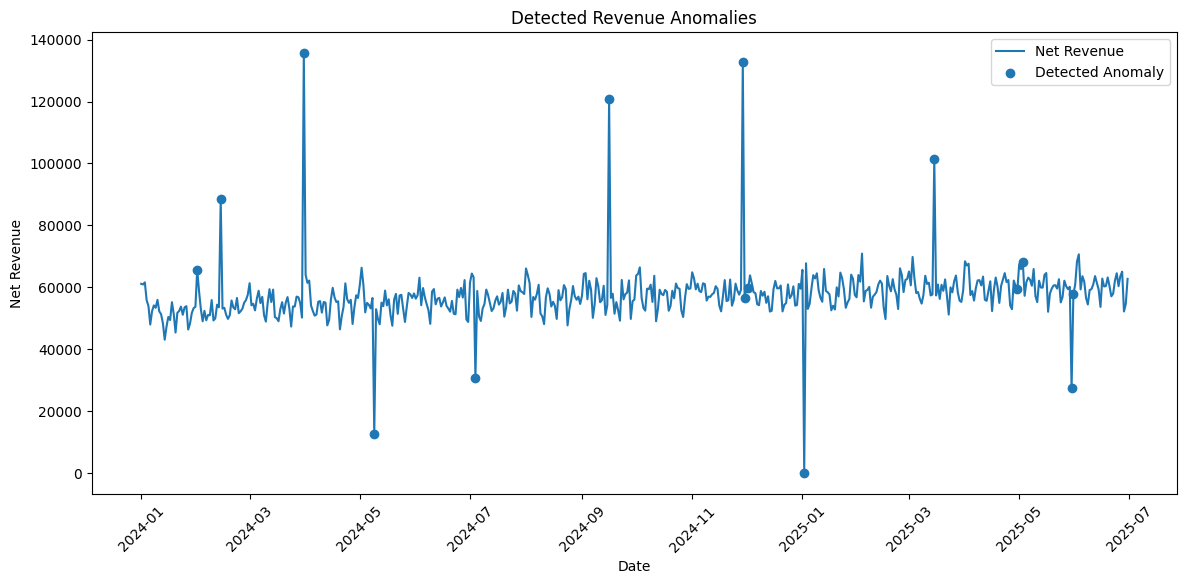

In [14]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['net_revenue'], label='Net Revenue')

anoms = df[df['final_anomaly'] == 1]
plt.scatter(anoms['date'], anoms['net_revenue'], label='Detected Anomaly')

plt.title('Detected Revenue Anomalies')
plt.xlabel('Date')
plt.ylabel('Net Revenue')
plt.legend()
plt.xticks(rotation=45)
plt.show()


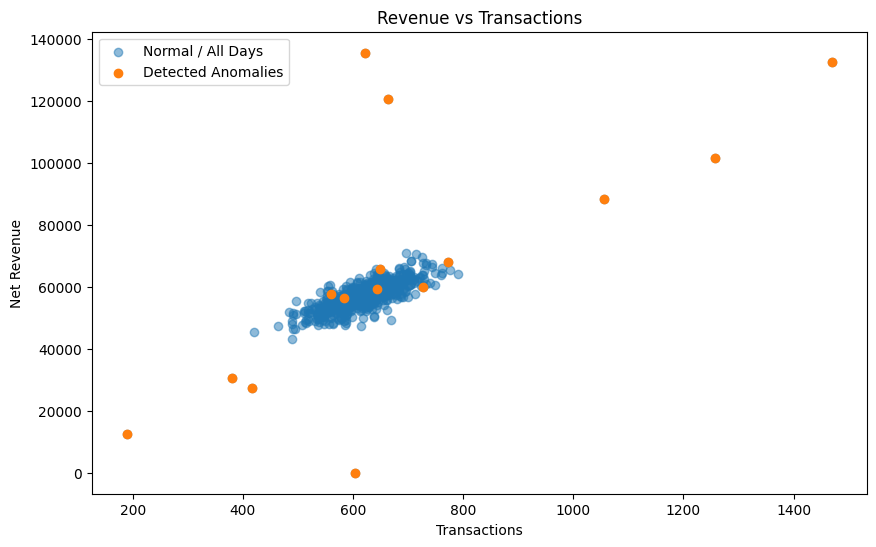

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(df['transactions'], df['net_revenue'], alpha=0.5, label='Normal / All Days')
plt.scatter(anoms['transactions'], anoms['net_revenue'], label='Detected Anomalies')
plt.title('Revenue vs Transactions')
plt.xlabel('Transactions')
plt.ylabel('Net Revenue')
plt.legend()
plt.show()


# 11. Model evaluation using synthetic truth labels

Because this is synthetic data, we know which days were injected as anomalies.

In real business data, you often do not have perfect labels. You evaluate by analyst review, incident tickets, finance reconciliation, or known business calendars.


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

print('Confusion Matrix')
print(confusion_matrix(df['is_known_anomaly'], df['final_anomaly']))

print('Classification Report')
print(classification_report(df['is_known_anomaly'], df['final_anomaly']))


Confusion Matrix
[[532   6]
 [  0   9]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       538
           1       0.60      1.00      0.75         9

    accuracy                           0.99       547
   macro avg       0.80      0.99      0.87       547
weighted avg       0.99      0.99      0.99       547



# 12. Final anomaly report for Finance team

In [18]:

anomaly_report = df[df['final_anomaly'] == 1][[
    'date', 'net_revenue', 'gross_revenue', 'transactions', 'new_customers',
    'refund_amount', 'failed_payments', 'chargebacks', 'marketing_spend',
    'enterprise_invoice_amount', 'payment_gateway_latency_ms', 'etl_delay_minutes',
    'rolling_anomaly_score', 'isolation_score', 'explanation_category',
    'severity', 'top_reasons', 'recommended_action', 'known_cause'
]].sort_values('date')

anomaly_report.to_csv('finance_revenue_anomaly_report.csv', index=False)
anomaly_report


,date,net_revenue,gross_revenue,transactions,new_customers,refund_amount,failed_payments,chargebacks,marketing_spend,enterprise_invoice_amount,payment_gateway_latency_ms,etl_delay_minutes,rolling_anomaly_score,isolation_score,explanation_category,severity,top_reasons,recommended_action,known_cause
31,2024-02-01,65743.095267,66586.001017,649,67,842.905750,42,3,1070.282406,0.0,239.928386,12,3.047016,0.038964,Unclear anomaly - needs analyst review,Medium,"Detected by multivariate pattern, but no singl...","Review revenue, payments, refunds, and data pi...",Normal business day
44,2024-02-14,88424.367546,90472.526346,1055,334,2048.158801,40,3,45182.546636,0.0,323.499991,7,4.600953,-0.099661,Campaign-driven spike,High,Revenue is 54% above 7-day average; Marketing ...,Validate campaign calendar and calculate campa...,Valentine promotion drove unusually high new s...
90,2024-03-31,135665.289550,136197.087092,621,58,531.797542,37,4,1190.348950,85000.0,265.508384,5,5.181775,-0.155831,Legitimate revenue spike,High,Revenue is 105% above 7-day average; Large ent...,Confirm invoice in billing system and exclude ...,Quarter-end enterprise invoice booked
129,2024-05-09,12533.009059,14018.727187,190,81,1485.718128,512,9,1650.721216,0.0,1764.355872,7,-4.642019,-0.195114,Possible fraud / disputed payments,High,Revenue is 75% below 7-day average; Failed pay...,Send cases to fraud/risk team and inspect cust...,Payment gateway outage caused failed payments ...
185,2024-07-04,30705.492097,31620.251636,381,38,914.759540,30,3,8873.811449,0.0,201.647821,6,-3.935659,-0.006368,Unclear anomaly - needs analyst review,High,Revenue is 44% below 7-day average,"Review revenue, payments, refunds, and data pi...",Holiday demand slowdown
259,2024-09-16,120742.199005,122973.425687,664,90,2231.226682,43,2,758.481746,0.0,207.201432,191,4.985529,-0.089214,Data pipeline / duplicate load issue,High,Revenue is 85% above 7-day average; ETL delay ...,"Check orchestration logs, duplicate transactio...",Duplicate billing / ETL duplicate load issue
333,2024-11-29,132656.186393,132999.255224,1469,489,343.068831,37,5,68667.923114,0.0,201.488472,7,5.177316,-0.189506,Campaign-driven spike,High,Revenue is 94% above 7-day average; Marketing ...,Confirm pricing campaign and evaluate margin i...,Black Friday campaign revenue spike
334,2024-11-30,56543.690067,57150.757919,583,70,607.067852,27,1,2239.744701,0.0,144.219352,7,-0.319465,-0.021542,Unclear anomaly - needs analyst review,Medium,"Detected by multivariate pattern, but no singl...","Review revenue, payments, refunds, and data pi...",Normal business day
336,2024-12-02,59845.977339,65722.367706,728,81,5876.390367,33,3,2685.676726,0.0,329.481038,5,-0.061897,-0.006426,Refund spike / revenue reversal,Medium,Failed payments or payment latency are unusual...,"Review refund batch, support tickets, and refu...",Normal business day
367,2025-01-02,0.000000,16077.153831,603,70,55795.702534,34,2,3027.798900,0.0,311.343386,9,-5.054446,-0.139715,Refund spike / revenue reversal,High,Revenue is 100% below 7-day average; Refund am...,"Review refund batch, support tickets, and refu...",Refund processing backlog released after holidays


# 13. Business interpretation examples

### Example 1: Positive spike
If revenue is high, new customers are high, and marketing spend is high:

> Likely a real campaign-driven revenue spike.

Finance action:

> Confirm campaign calendar and calculate return on ad spend.

---

### Example 2: Revenue spike but transactions are normal
If revenue is very high but transactions barely moved:

> Could be enterprise invoice, duplicate billing, or ETL duplicate load.

Finance action:

> Reconcile billing system, invoice system, and warehouse transaction counts.

---

### Example 3: Revenue drop with failed payments
If revenue is low and failed payments / gateway latency are high:

> Likely payment gateway outage.

Finance action:

> Trigger retry jobs and estimate lost revenue.

---

### Example 4: Revenue drop with high refunds
If net revenue drops because refund amount is high:

> Refund backlog or product/customer issue.

Finance action:

> Review refund reason codes and support tickets.

---

### Example 5: Revenue spike with high chargebacks
If revenue and chargebacks both increase:

> Possible fraud or suspicious payment burst.

Finance action:

> Send to fraud/risk team.
